In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

seq = '1352435'
seq = [int(i) for i in seq]
n_fingers = 5
force_duration = 200 # ms
max_force = 1 # N

# sampling resolution 
sampling_freq = 5

def generate_gaussian_force():
    """Generate a Gaussian force profile for a single finger."""
    t = np.linspace(0, force_duration, force_duration)
    force = max_force * np.exp(-((t - force_duration / 2) ** 2) / (2 * (force_duration / 6) ** 2))
    return t, force

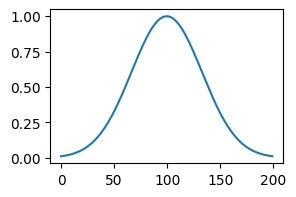

In [84]:
t, force = generate_gaussian_force()
plt.figure(figsize = (3,2))
plt.plot(force)

In [85]:
def generate_press_force(forces, finger, start_time):
    # generate a gaussian force profile for a finger press
    forces[finger, start_time:start_time + force_duration] = force
    return forces


def generate_press_sequence(seq, inter_press_interval):
    """Generate a force profile for a sequence of finger presses."""
    forces = np.zeros((n_fingers, len(seq) * force_duration + (len(seq) - 1) * inter_press_interval))
    
    for i, finger in enumerate(seq):
        start_time = (i) * inter_press_interval + i * force_duration
        forces = generate_press_force(forces, finger - 1, start_time)
    
    return forces
    

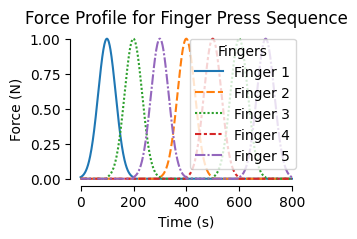

In [86]:
inter_press_interval = -100 # ms
forces = generate_press_sequence(seq, inter_press_interval)
# Convert to DataFrame for easier plotting
df = pd.DataFrame(forces.T, columns=[f'Finger {i+1}' for i in range(n_fingers)])
df['Time'] = np.arange(len(df))
# Plotting the force profile
plt.figure(figsize=(3, 2))
sns.lineplot(data=df.set_index('Time'))
plt.title('Force Profile for Finger Press Sequence')
plt.xlabel('Time (s)')
plt.ylabel('Force (N)')
plt.legend(title='Fingers')
sns.despine(trim=True)
# plt.grid()
plt.show()



In [99]:
# calculate inter-press intervals from execution time

def calculate_inter_press_intervals(seq, ET):
    inter_press_interval = (ET - len(seq) * force_duration) / (len(seq) - 1)
    return int(inter_press_interval)

# generate execution times with an exponential 
def generate_execution_times(seq, init_time):
    a = 2000
    b = 0.05
    c = 800 # ms
    execution_times = []
    n_trials = 100
    for i in range(n_trials):
        ET = a * np.exp(-b * i) + c
        execution_times.append(ET)
    return execution_times

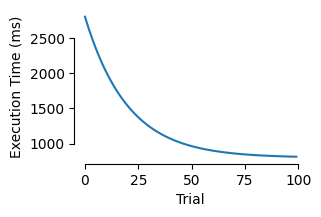

In [100]:
init_exec_time = 3000 # ms
execution_times = generate_execution_times(seq, init_exec_time)
plt.figure(figsize=(3, 2))
plt.plot(execution_times)
plt.xlabel('Trial')
plt.ylabel('Execution Time (ms)')
sns.despine(trim=True)

In [101]:
def linearly_sampling_force(forces, n_samples=300):
    new_forces = np.zeros((forces.shape[0], n_samples))
    for finger in range(n_fingers):
        force = forces[finger, :]
        force = np.interp(np.linspace(0, len(force) - 1, n_samples), np.arange(len(force)), force)
        new_forces[finger, :] = force
    return new_forces

def sample_with_frequency(force, freq):
    """Sample the force profile at a given frequency."""
    sampled_forces = force[:, ::freq]
    return sampled_forces

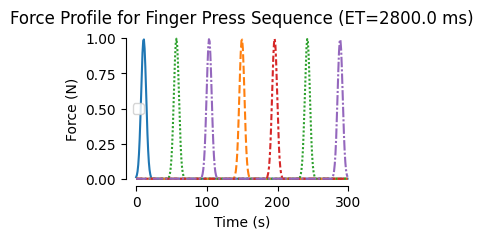

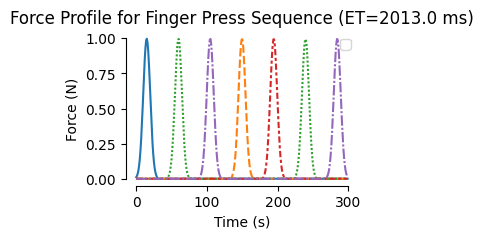

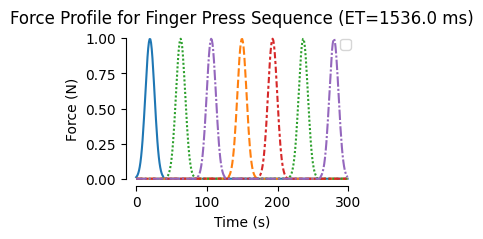

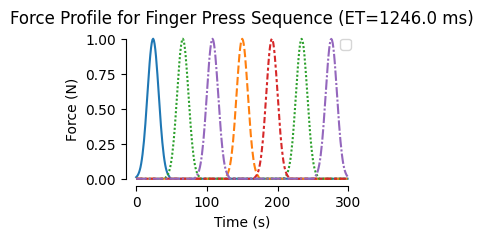

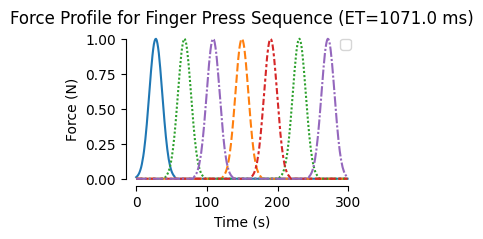

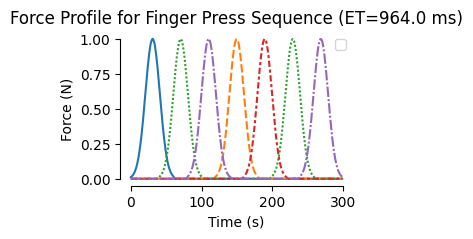

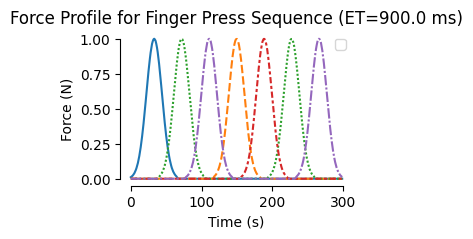

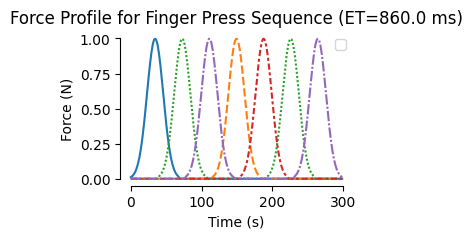

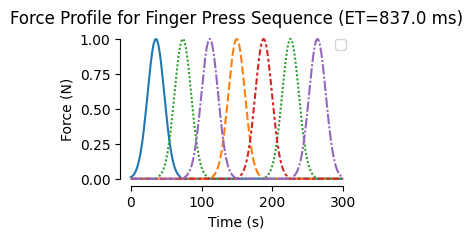

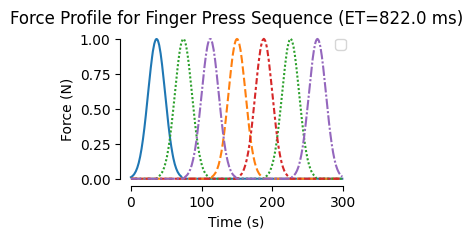

In [102]:
all_forces = []
for trial, ET in enumerate(execution_times):
    inter_press_interval = calculate_inter_press_intervals(seq, ET)
    forces = generate_press_sequence(seq, inter_press_interval)
    forces = sample_with_frequency(forces, sampling_freq)
    forces = linearly_sampling_force(forces)
    all_forces.append({
        'trial': trial,
        'ET': ET,
        'forces': forces
    })
    df = pd.DataFrame(forces.T, columns=[f'Finger {i+1}' for i in range(n_fingers)])
    df['Time'] = np.arange(len(df))

    if trial % 10 == 0:
    
        # Plotting the force profile
        plt.figure(figsize=(3, 2))
        sns.lineplot(data=df.set_index('Time'))
        plt.title(f'Force Profile for Finger Press Sequence (ET={np.round(ET)} ms)')
        plt.xlabel('Time (s)')
        plt.ylabel('Force (N)')
        plt.legend(title='Fingers')
        plt.legend([])
        sns.despine(trim=True)
        # plt.grid()
        plt.show()


all_forces = pd.DataFrame(all_forces)

In [103]:
# variance of execution times over learning

moving_window = 10
vars = []
for i in range(len(all_forces) - moving_window):
    window_data = all_forces.iloc[i:i + moving_window]
    var = np.std(window_data['ET'].values)
    vars.append(var)



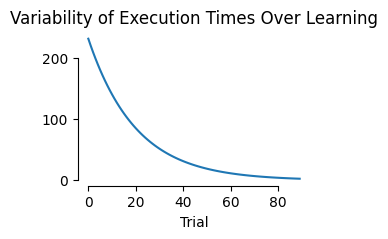

In [104]:
plt.figure(figsize = (3,2))
plt.plot(vars)
plt.title('Variability of Execution Times Over Learning')
plt.xlabel('Trial')

sns.despine(trim=True)

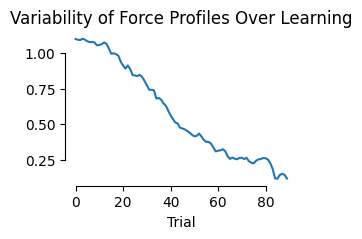

In [105]:
plt.figure(figsize=(3,2))
moving_window = 10
vars = []
for i in range(len(all_forces) - moving_window):
    window_data = all_forces.iloc[i:i + moving_window]
    force_vectors = np.array(window_data['forces'].values.tolist())
    mean_force = np.mean(window_data['forces'].values, axis=0)
    var = np.sqrt(np.sum(((force_vectors - mean_force) ** 2), axis = (1,2)).mean())
    vars.append(var)


plt.plot(vars)
plt.title('Variability of Force Profiles Over Learning')
plt.xlabel('Trial')
sns.despine(trim=True)
plt.show()


